# Examples: Plotting

Below are examples of data aggregation and plotting functions that can be used to visualize the data.

In [1]:
import cns
import cns.data_utils as cdu
import matplotlib.pyplot as plt

## Labeling functions

These functions create background/s labels independent of the data.

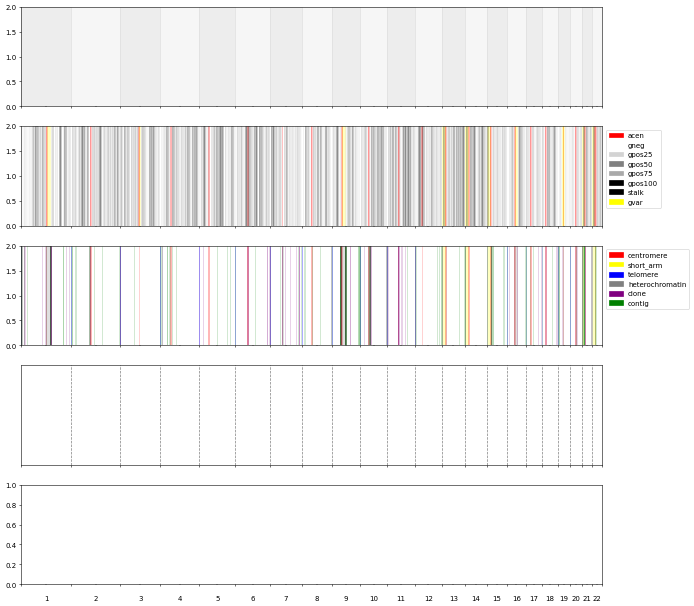

In [ ]:
fig, axs = plt.subplots(5,1, figsize=(15, 15), sharex=True, dpi=50)
cns.plot_chr_bg(axs[0])

cns.plot_cytobands(axs[1], alpha=.25)
cns.add_cytoband_legend(axs[1])

cns.plot_gaps(axs[2], alpha=.25)
cns.add_gap_legend(axs[2])

cns.plot_x_ticks(axs[3])
cns.plot_x_lines(axs[3])
cns.no_y_ticks(axs[3])

## Prepare Data

Loads and aggregates the data.

In [5]:
pcawg_cns_df = cns.add_total_cn(cdu.load_cns_file("PCAWG_cns_imp.tsv"))
pcawg_cns_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn
0,SP101724,chr1,0,27256755,2.0,2.0,4.0
1,SP101724,chr1,27256755,28028200,3.0,2.0,5.0
2,SP101724,chr1,28028200,32976095,2.0,2.0,4.0
3,SP101724,chr1,32976095,33354394,5.0,2.0,7.0
4,SP101724,chr1,33354394,33554783,3.0,2.0,5.0


In [6]:
genes_segs = cdu.load_segs_out("segs_COSMIC.bed")

pcawg_1_bin_df = cns.aggregate_by_break_type(cns.cns_head(pcawg_cns_df, 1), 100_000)
pcawg_1_groups_df = cns.group_samples(pcawg_1_bin_df, group_name="100 kb")

pcawg_10_bin_df = cns.aggregate_by_break_type(cns.cns_head(pcawg_cns_df, 10), 1_000_000)
pcawg_10_groups_df = cns.group_samples(pcawg_10_bin_df, group_name="1 mb")

pcawg_50_bin_df = cns.aggregate_by_break_type(cns.cns_head(pcawg_cns_df, 50), 10_000_000)
pcawg_50_groups_df = cns.group_samples(pcawg_50_bin_df, group_name="10 mb")

pcawg_arms_bin_df = cns.aggregate_by_break_type(cns.cns_head(pcawg_cns_df, 10), "arms")
pcawg_arms_groups_df = cns.group_samples(pcawg_arms_bin_df, group_name="arms")

gene_bin_df = cns.aggregate_by_segments(cns.cns_head(pcawg_cns_df, 10), genes_segs)
gene_groups_df = cns.group_samples(gene_bin_df, group_name="COSMIC")

Aggregated into 30363 CNS.                                        
Aggregated into 30399 CNS.                                        
Aggregated into 15256 CNS.                                        
Aggregated into 462 CNS.                                        
Aggregated into 7220 CNS.                                        


## Plots

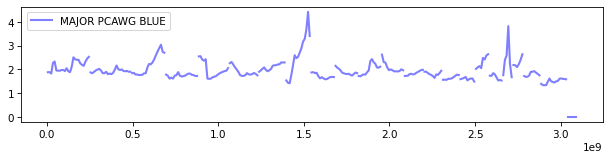

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
cns.plot_lines(ax, pcawg_50_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

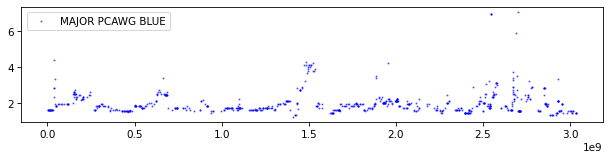

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
cns.plot_dots(ax, gene_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 1)
ax.legend()

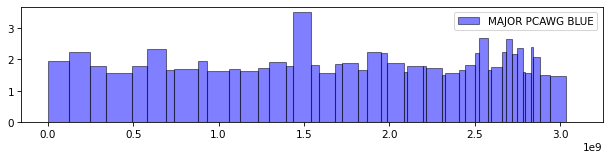

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
cns.plot_bars(ax, pcawg_arms_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5)
ax.legend()

<Axes: >

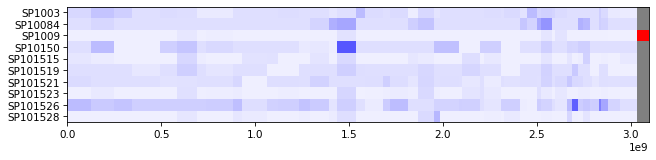

In [10]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=75)
cns.plot_heatmap(ax, pcawg_arms_bin_df, "major_cn", max_cn = 16)

## Figures

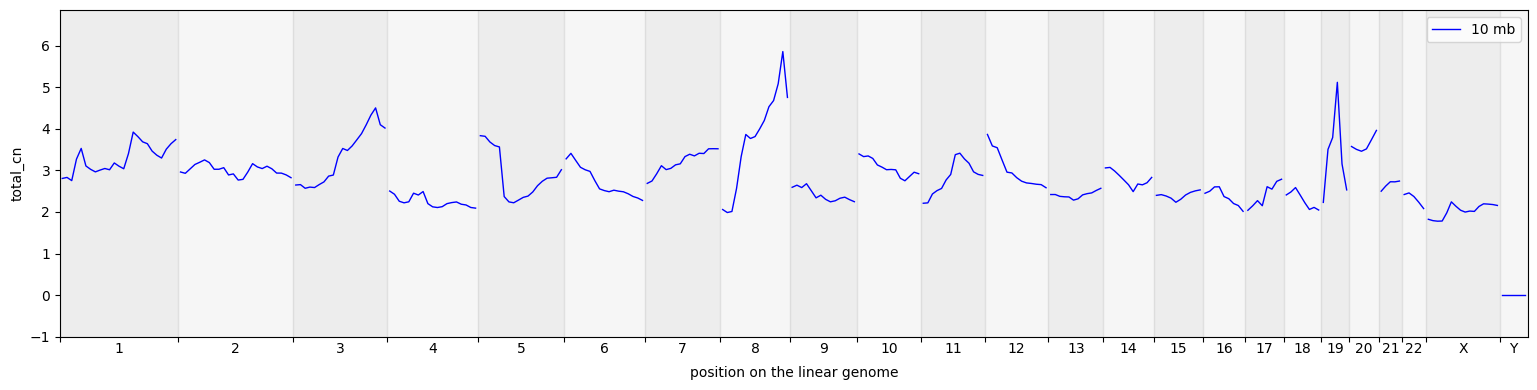

In [11]:
cns.fig_lines(pcawg_50_groups_df, cn_columns="total_cn", colors="blue");

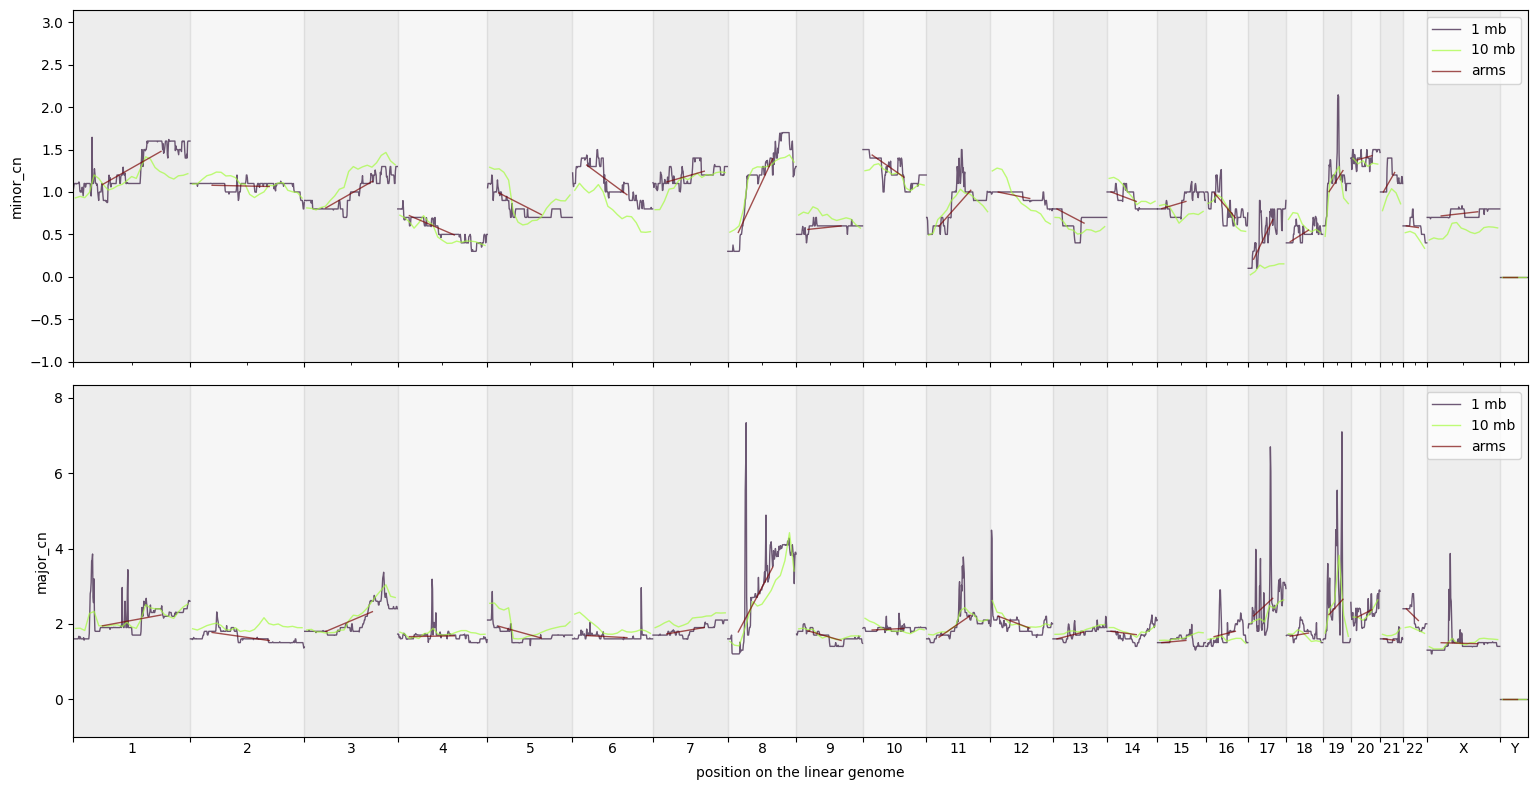

In [12]:
groups_df = cns.stack_groups([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df])
cns.fig_lines(groups_df, cn_columns=["minor_cn", "major_cn"]);

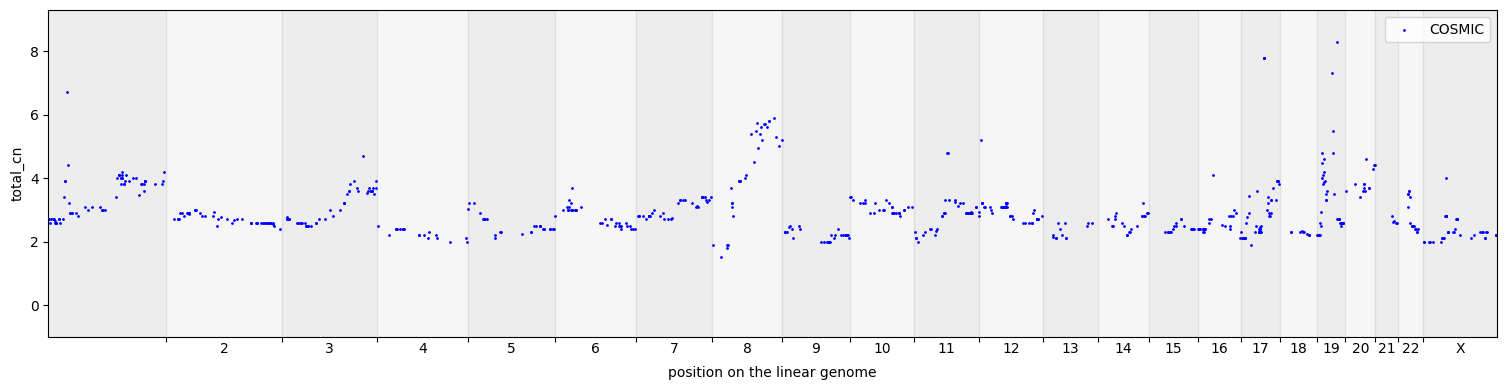

In [13]:
cns.fig_dots(gene_groups_df, cn_columns="total_cn");

(<Figure size 1516.62x1200 with 3 Axes>,
 array([<Axes: ylabel='major_cn'>, <Axes: ylabel='minor_cn'>,
        <Axes: xlabel='position on the linear genome', ylabel='total_cn'>],
       dtype=object))

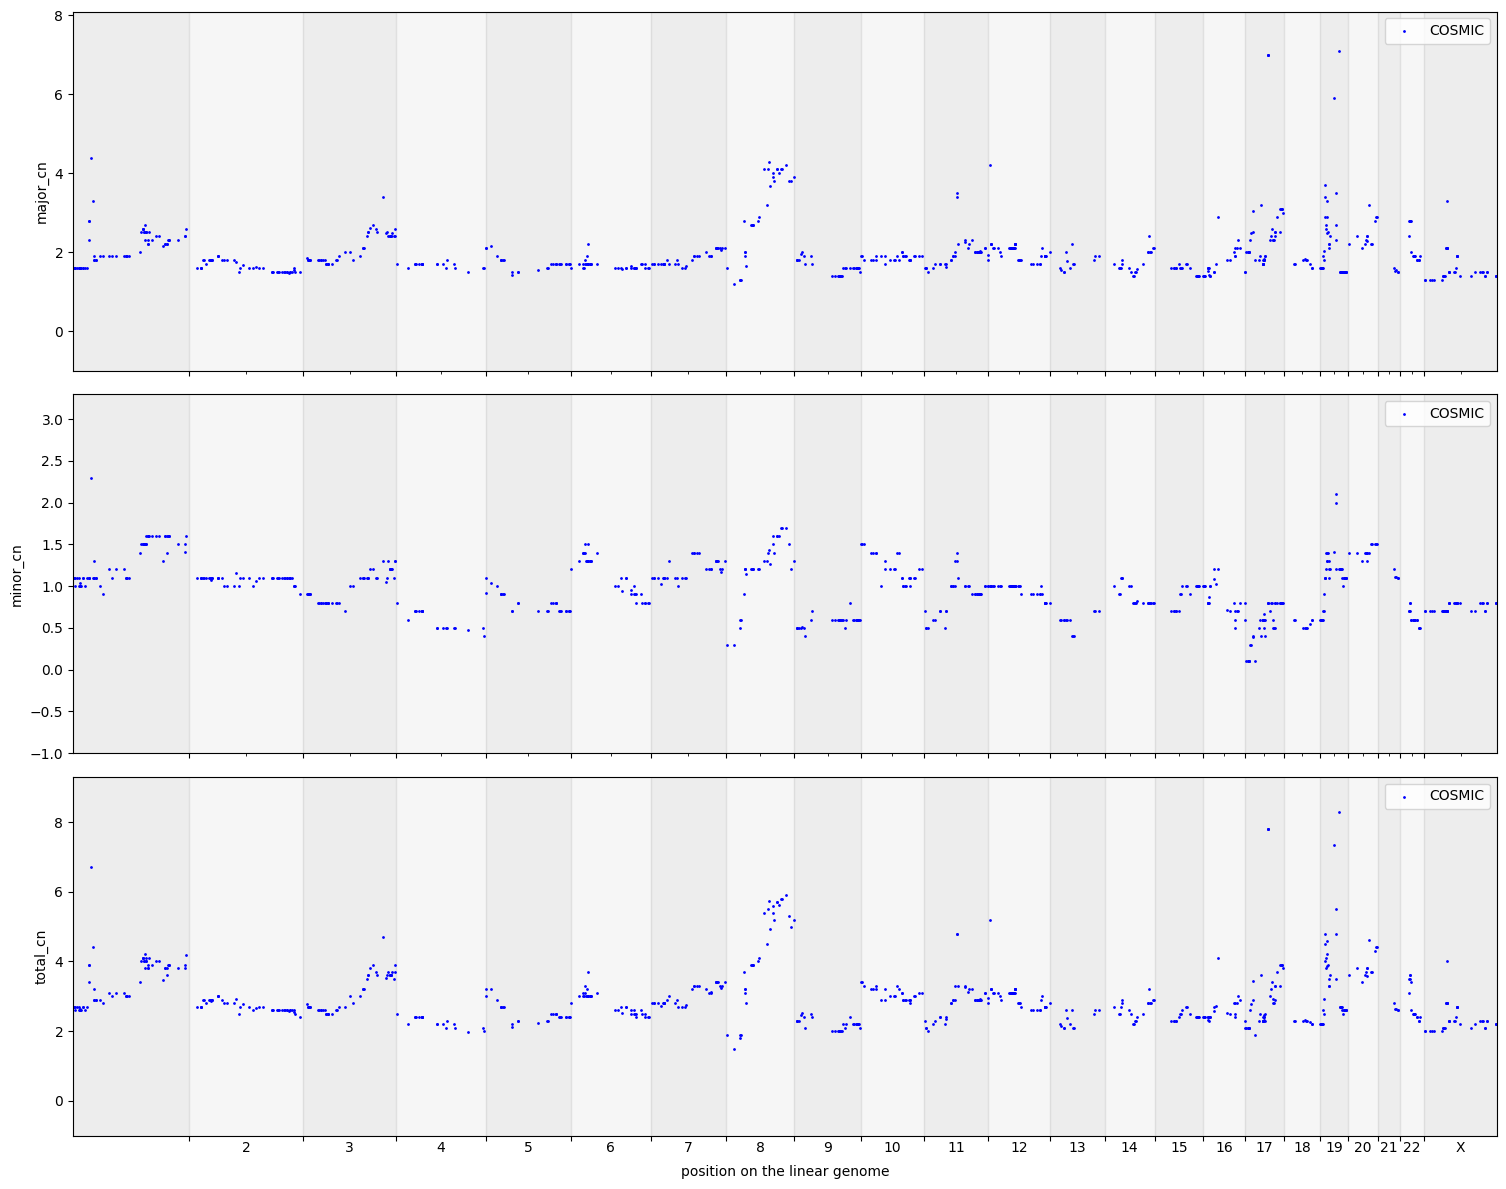

In [14]:
cns.fig_dots(gene_groups_df)

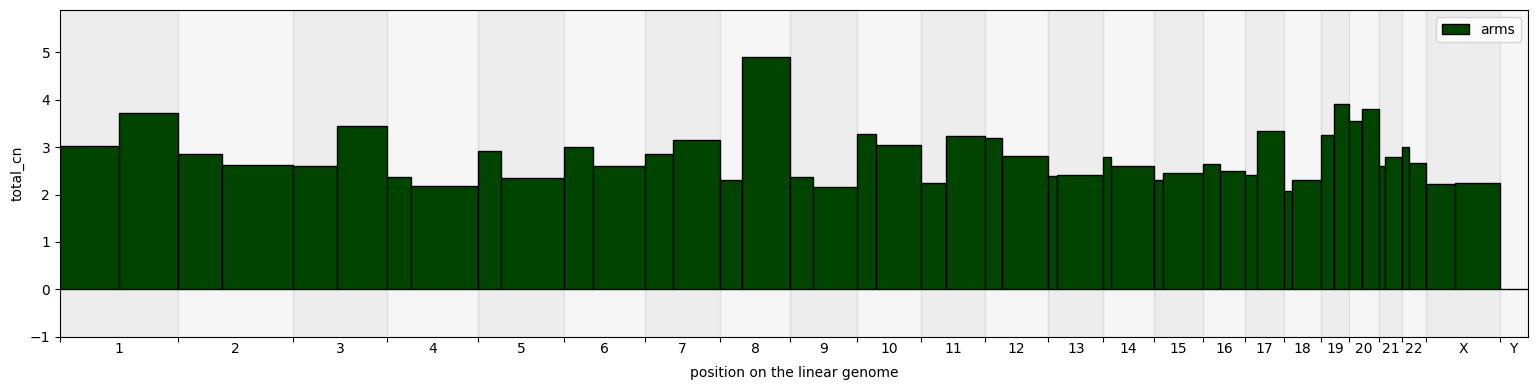

In [15]:
cns.fig_bars(pcawg_arms_groups_df, cn_columns="total_cn", colors="#004400");

(<Figure size 1547.84x800 with 2 Axes>,
 array([<Axes: ylabel='minor_cn'>,
        <Axes: xlabel='position on the linear genome', ylabel='major_cn'>],
       dtype=object))

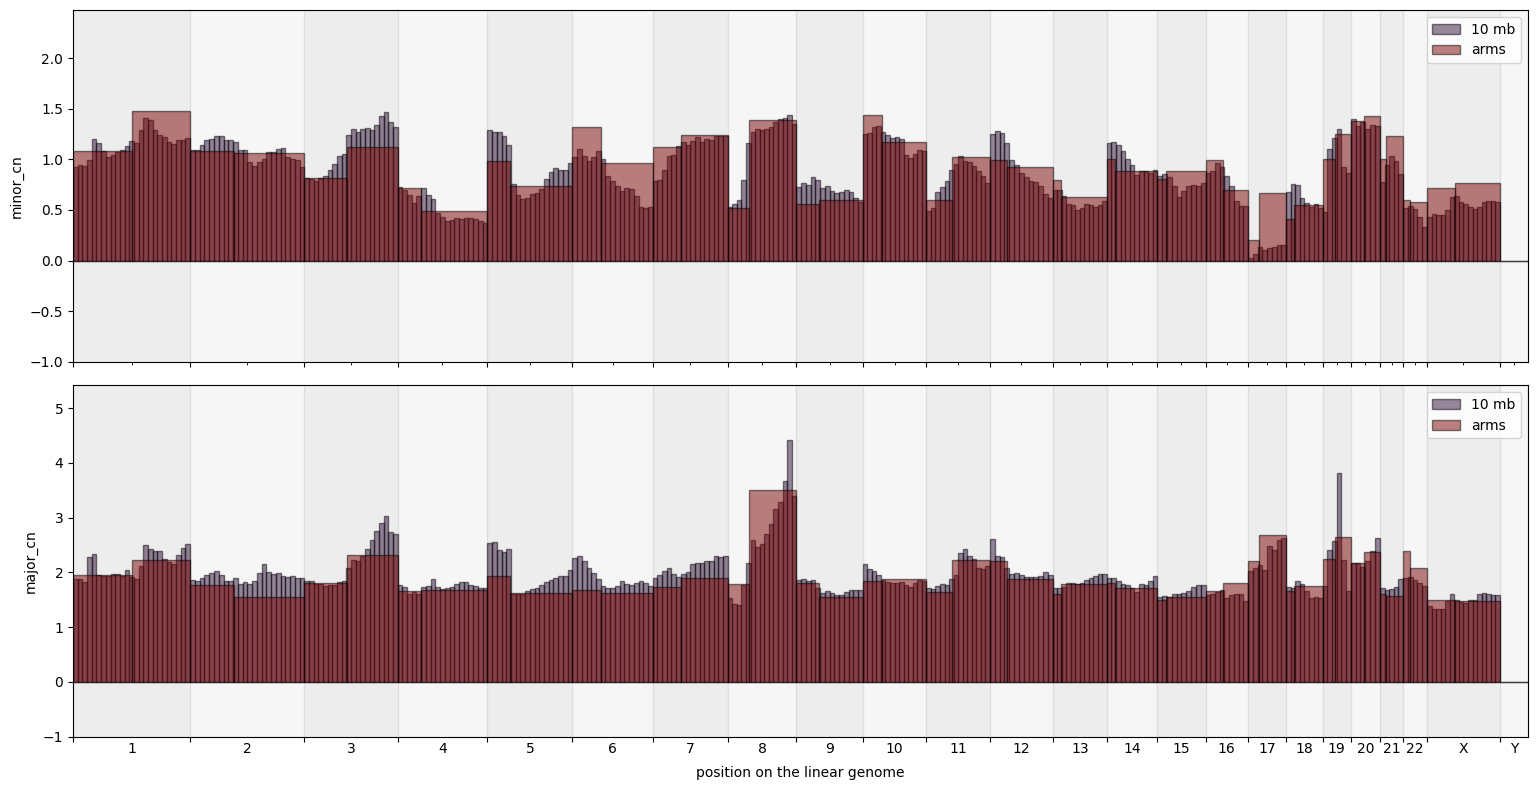

In [16]:
big_groups = cns.stack_groups([pcawg_50_groups_df, pcawg_arms_groups_df])
cns.fig_bars(big_groups, cn_columns=["minor_cn", "major_cn"])

##  Filter for single chromosome

In [17]:
step = int(1e6)
filtered_cns = cns.main_seg_agg(cns.cns_head(pcawg_cns_df, 10), ["total_cn"], cns.regions_select("whole"), cns.regions_select("gaps"), split_size=step, filter_size=step//2)

ValueError: input_data must be a CNS DataFrame, a segments dictionary or one of of ['whole', 'arms', 'bands'], got <class 'list'>

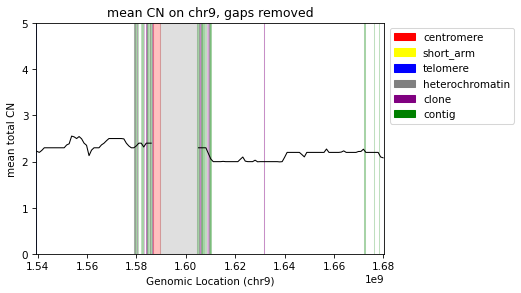

In [ ]:
grouped_bins = cns.group_samples(filtered_cns).query("chrom == 'chr9'")
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=75)
cns.plot_gaps(ax, alpha=.25, y_max=5)
cns.add_gap_legend(ax)
cns.plot_lines(ax, grouped_bins, "total_cn", color="black")
ax.set_xlim(*cns.x_limits(grouped_bins))
# no_y_ticks(ax)
ax.set_ylabel("mean total CN")
ax.set_xlabel("Genomic Location (chr9)")
ax.set_title("mean CN on chr9, gaps removed")
cdu.save_doc_fig("fig_gaps_removed_chr9")	

## CN Heatmaps

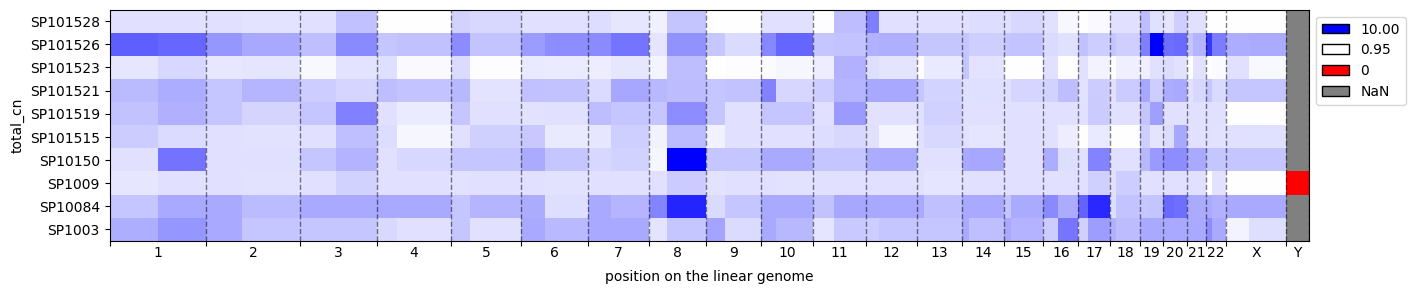

In [ ]:
cns.fig_heatmap(pcawg_arms_bin_df, cn_columns="total_cn")

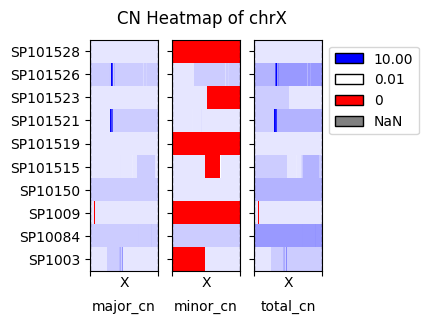

In [ ]:
fig, axs = cns.fig_heatmap(pcawg_10_bin_df.query("chrom == 'chrX'"), max_cn=10, vertical=False)
fig.suptitle("CN Heatmap of chrX")